# 📈 SBER 5-Minute Intraday Research Pipeline

**Goal:** feature engineering on raw Finam OHLCV candles → CatBoost classifier → probability calibration → feature importance.

**Target variable (обновлён 2026-05-02):** `target_is_green_next = 1`, если **движение CLOSE за следующие `K_BARS=3` свечи (15 мин) ≥ `K_ATR=1.0` × ATR(14)**; `0`, если движение ≤ −1·ATR; иначе строка отбрасывается как «шумная» (нет значимого движения).

> Этот target пришёл из эксперимента **A3** + sensitivity grid. Базовый target «зелёная свеча» давал AUC≈0.52 OOS — слишком близко к шуму. ATR-target отфильтровывает ~65% малозначимых баров и поднимает AUC до **~0.58–0.61 OOS** при симметричных хвостах LONG/SHORT (precision ≈ 0.57–0.66 на сотнях сигналов). Логика: модель учится на барах, где рынок реально движется на ≥1·ATR за 15 минут, и игнорирует флэт.

**Модель: CatBoost** (победитель model zoo, см. README → раздел Model zoo). Дала AUC OOS на +4pp выше XGBoost, оба хвоста с prec ≥0.56 на сотнях сигналов.

**Important:** all features use only current-bar-close or past-bar data. No look-ahead bias (см. историческую правку DPO в README → Results).


## Cell 1 — Imports & Display Settings

In [1]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pandas import DataFrame, concat
from IPython.display import display

import pandas_ta as ta

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (15, 5)

import sklearn
from packaging.version import Version
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
# FrozenEstimator появился в sklearn 1.6+; используется как замена cv='prefit',
# который удалён в sklearn 1.8.
try:
    from sklearn.frozen import FrozenEstimator
    _HAS_FROZEN = True
except ImportError:
    FrozenEstimator = None
    _HAS_FROZEN = False
from sklearn.metrics import (
    accuracy_score, roc_auc_score, log_loss,
    brier_score_loss, classification_report, confusion_matrix,
)
from sklearn.inspection import permutation_importance
from catboost import CatBoostClassifier

# ── sklearn version compatibility ─────────────────────────────────────────
_SKLEARN_VERSION = Version(sklearn.__version__)
_CALIB_ESTIMATOR_KWARG = 'estimator' if _SKLEARN_VERSION >= Version('1.2') else 'base_estimator'

print('Python:', sys.version)
print('pandas:', pd.__version__)
print('numpy:', np.__version__)
print('sklearn:', sklearn.__version__)
print('catboost:', __import__('catboost').__version__)
print(f'CalibratedClassifierCV kwarg: "{_CALIB_ESTIMATOR_KWARG}"')
print('All imports OK ✓')

Python: 3.12.8 (main, Apr 28 2026, 02:56:29) [GCC 14.2.0]
pandas: 3.0.2
numpy: 2.2.6
sklearn: 1.8.0
catboost: 1.2.10
CalibratedClassifierCV kwarg: "estimator"
All imports OK ✓


## Cell 2 — Helper: series_to_supervised

In [2]:
def series_to_supervised(data, n_in=1, n_out=1, dropnan=True):
    n_vars = 1 if type(data) is list else data.shape[1]
    df = DataFrame(data)
    col_list = data.columns.tolist()
    cols, names = list(), list()
    for i in range(n_in, 0, -1):
        cols.append(df.shift(i))
        names += [('%s_%d(t-%d)' % (col_list[j], j+1, i)) for j in range(n_vars)]
    for i in range(0, n_out):
        cols.append(df.shift(-i))
        if i == 0:
            names += [('%s_var%d(t)' % (col_list[j], j+1)) for j in range(n_vars)]
        else:
            names += [('%s_var%d(t+%d)' % (col_list[j], j+1, i)) for j in range(n_vars)]
    agg = concat(cols, axis=1)
    agg.columns = names
    if dropnan:
        agg.dropna(inplace=True)
    return agg

print('series_to_supervised defined ✓')

series_to_supervised defined ✓


## Cell 3 — Feature Engineering Functions

In [3]:
EPS = 1e-12
DATA_PATH = './Сбербанк/year_result.csv'

def prepare_ohlcv_dataframe(df):
    required = {'OPEN', 'HIGH', 'LOW', 'CLOSE', 'VOL'}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f'Missing required columns: {sorted(missing)}')
    out = df.copy(deep=True)
    for col in ['OPEN', 'HIGH', 'LOW', 'CLOSE', 'VOL']:
        out[col] = pd.to_numeric(out[col], errors='coerce')
    if {'DATE', 'TIME'}.issubset(out.columns):
        date_str = out['DATE'].astype(str).str.strip()
        time_str = out['TIME'].astype(str).str.zfill(6).str.strip()
        out['datetime'] = pd.to_datetime(date_str + time_str, format='%Y%m%d%H%M%S', errors='coerce')
        out = out.sort_values('datetime', kind='stable').reset_index(drop=True)
    return out

def add_domain_features(df):
    out = df.copy(deep=True)
    rng = out['HIGH'] - out['LOW']
    safe_rng = rng.where(rng.abs() > EPS, np.nan)
    max_oc = np.maximum(out['OPEN'], out['CLOSE'])
    min_oc = np.minimum(out['OPEN'], out['CLOSE'])
    prev_close = out['CLOSE'].shift(1)
    prev_high = out['HIGH'].shift(1)
    prev_low = out['LOW'].shift(1)
    out['candle_body'] = out['CLOSE'] - out['OPEN']
    out['body_abs'] = out['candle_body'].abs()
    out['candle_range'] = rng
    out['upper_wick'] = out['HIGH'] - max_oc
    out['lower_wick'] = min_oc - out['LOW']
    out['body_to_range'] = (out['body_abs'] / safe_rng).clip(0, 1)
    out['upper_wick_to_range'] = (out['upper_wick'] / safe_rng).clip(0, 1)
    out['lower_wick_to_range'] = (out['lower_wick'] / safe_rng).clip(0, 1)
    out['close_pos_in_range'] = ((out['CLOSE'] - out['LOW']) / safe_rng).clip(0, 1)
    out['open_pos_in_range'] = ((out['OPEN'] - out['LOW']) / safe_rng).clip(0, 1)
    out['direction'] = np.sign(out['candle_body']).astype('float64')
    out['is_green'] = (out['CLOSE'] > out['OPEN']).astype('int8')
    out['is_red'] = (out['CLOSE'] < out['OPEN']).astype('int8')
    out['is_doji_like'] = (out['body_to_range'] <= 0.1).astype('int8')
    out['ret_1'] = out['CLOSE'].pct_change(1)
    out['gap_from_prev_close'] = out['OPEN'] / prev_close - 1.0
    out['close_to_prev_high'] = out['CLOSE'] / prev_high - 1.0
    out['close_to_prev_low'] = out['CLOSE'] / prev_low - 1.0
    out['range_pct_close'] = out['candle_range'] / out['CLOSE'].replace(0, np.nan)
    out['body_x_vol'] = out['body_abs'] * out['VOL']
    out['signed_vol'] = out['direction'] * out['VOL']
    out['money_flow_proxy'] = ((out['CLOSE'] - out['LOW']) - (out['HIGH'] - out['CLOSE'])) / safe_rng * out['VOL']
    return out

def add_rolling_features(df, windows=(6, 12, 24)):
    out = df.copy(deep=True)
    for w in windows:
        out[f'ret_{w}'] = out['CLOSE'].pct_change(w)
        rng_mean = out['candle_range'].rolling(w, min_periods=w).mean()
        rng_std = out['candle_range'].rolling(w, min_periods=w).std()
        out[f'range_mean_{w}'] = rng_mean
        out[f'range_std_{w}'] = rng_std
        out[f'range_zscore_{w}'] = (out['candle_range'] - rng_mean) / rng_std.replace(0, np.nan)
        out[f'body_mean_{w}'] = out['body_abs'].rolling(w, min_periods=w).mean()
        close_ma = out['CLOSE'].rolling(w, min_periods=w).mean()
        close_std = out['CLOSE'].rolling(w, min_periods=w).std()
        out[f'close_ma_{w}'] = close_ma
        out[f'close_vs_ma_{w}'] = out['CLOSE'] / close_ma - 1.0
        out[f'close_zscore_{w}'] = (out['CLOSE'] - close_ma) / close_std.replace(0, np.nan)
        vol_ma = out['VOL'].rolling(w, min_periods=w).mean()
        out[f'vol_ma_{w}'] = vol_ma
        out[f'vol_ratio_{w}'] = out['VOL'] / vol_ma.replace(0, np.nan)
    return out

def add_calendar_features(df):
    if 'datetime' not in df.columns:
        raise ValueError("Column 'datetime' not found. Run prepare_ohlcv_dataframe first.")
    out = df.copy(deep=True)
    dt = out['datetime']
    out['hour'] = dt.dt.hour
    out['minute'] = dt.dt.minute
    out['dayofweek'] = dt.dt.dayofweek
    out['hour_sin'] = np.sin(2 * np.pi * out['hour'] / 24)
    out['hour_cos'] = np.cos(2 * np.pi * out['hour'] / 24)
    out['dow_sin'] = np.sin(2 * np.pi * out['dayofweek'] / 5)
    out['dow_cos'] = np.cos(2 * np.pi * out['dayofweek'] / 5)
    out['minutes_from_session_open'] = out['hour'] * 60 + out['minute'] - 600
    out['is_opening_30m'] = (out['minutes_from_session_open'] < 30).astype('int8')
    out['is_first_hour'] = (out['minutes_from_session_open'] < 60).astype('int8')
    out['date_only'] = dt.dt.date
    out['bar_in_day'] = out.groupby('date_only').cumcount()
    out['is_first_bar_of_day'] = (out['bar_in_day'] == 0).astype('int8')
    out = out.drop(columns=['date_only'])
    return out

def add_ta_features(df, verbose=True):
    """Генерация полного набора TA-признаков через pandas_ta.

    Каждая группа индикаторов обёрнута в try/except: если индикатор недоступен
    в установленной версии pandas_ta или возвращает None — он пропускается
    с предупреждением. Заведомо рискованные на look-ahead индикаторы исключены:
      - ichimoku forward-колонки (ISA_/ISB_ со сдвигом senkou вперёд),
      - vp (volume profile, требует полной серии),
      - psar в реализации, заглядывающей вперёд (оставляем только если
        реализация причинно-следственная — значение в момент t зависит от данных
        до момента t включительно; pandas_ta даёт такую реализацию).
    """
    out = df.copy(deep=True)
    initial_cols = set(out.columns)
    skipped = []  # Список пропущенных индикаторов (имя -> причина)

    def _try(name, fn):
        """Применить функцию-индикатор; пропустить и залогировать при ошибке."""
        try:
            res = fn()
            if res is None:
                skipped.append((name, 'returned None'))
                return None
            return res
        except Exception as e:
            skipped.append((name, f'{type(e).__name__}: {e}'))
            return None

    def _add_series(name, fn):
        """Добавить одиночный Series как колонку."""
        res = _try(name, fn)
        if res is not None:
            out[name] = res

    def _add_frame(name, fn, drop_cols=None):
        """Добавить DataFrame (concat); опционально удалить указанные колонки."""
        res = _try(name, fn)
        if res is not None:
            if drop_cols:
                cols_to_drop = [c for c in res.columns if any(d in c for d in drop_cols)]
                if cols_to_drop:
                    res = res.drop(columns=cols_to_drop)
            # Защита от коллизий имён
            res = res.loc[:, ~res.columns.duplicated()]
            new_cols = [c for c in res.columns if c not in out.columns]
            if new_cols:
                out[new_cols] = res[new_cols]

    # ── TREND ────────────────────────────────────────────────────────────────
    _add_series('ema_10',  lambda: ta.ema(out['CLOSE'], length=10))
    _add_series('ema_20',  lambda: ta.ema(out['CLOSE'], length=20))
    _add_series('ema_50',  lambda: ta.ema(out['CLOSE'], length=50))
    _add_series('sma_20',  lambda: ta.sma(out['CLOSE'], length=20))
    _add_series('sma_50',  lambda: ta.sma(out['CLOSE'], length=50))
    _add_series('wma_14',  lambda: ta.wma(out['CLOSE'], length=14))
    _add_series('dema_10', lambda: ta.dema(out['CLOSE'], length=10))
    _add_series('tema_10', lambda: ta.tema(out['CLOSE'], length=10))
    _add_series('trima_14',lambda: ta.trima(out['CLOSE'], length=14))
    _add_series('vwma_14', lambda: ta.vwma(out['CLOSE'], out['VOL'], length=14))
    # ichimoku — оставляем только tenkan/kijun/chikou (без forward-сдвига senkou),
    # поскольку ISA_/ISB_ со сдвигом вперёд ведут к look-ahead bias.
    _add_frame('ichimoku', lambda: ta.ichimoku(out['HIGH'], out['LOW'], out['CLOSE'])[0],
               drop_cols=['ISA_', 'ISB_'])
    # psar — pandas_ta использует причинную реализацию (значение в t зависит
    # только от прошлого), поэтому добавляем. PSARl и PSARs — взаимно
    # разреженные (либо long, либо short в каждый момент), поэтому объединяем
    # их в единую колонку psar_value, иначе dropna() уничтожит все строки.
    psar_df = None
    try:
        psar_df = ta.psar(out['HIGH'], out['LOW'], out['CLOSE'])
    except Exception as e:
        skipped.append(('psar', f'{type(e).__name__}: {e}'))
    if psar_df is not None:
        # Объединяем PSARl/PSARs → psar_value (одно из двух всегда определено)
        psarl_col = next((c for c in psar_df.columns if c.startswith('PSARl_')), None)
        psars_col = next((c for c in psar_df.columns if c.startswith('PSARs_')), None)
        if psarl_col and psars_col:
            out['psar_value'] = psar_df[psarl_col].fillna(psar_df[psars_col])
            out['psar_is_long'] = psar_df[psarl_col].notna().astype('int8')
        # Прочие колонки PSAR (af — фактор ускорения, r — индикатор разворота)
        for c in psar_df.columns:
            if c.startswith('PSARaf_') or c.startswith('PSARr_'):
                out[c] = psar_df[c]
    _add_frame('adx_14',   lambda: ta.adx(out['HIGH'], out['LOW'], out['CLOSE'], length=14))
    _add_frame('aroon_14', lambda: ta.aroon(out['HIGH'], out['LOW'], length=14))
    _add_series('cci_14',  lambda: ta.cci(out['HIGH'], out['LOW'], out['CLOSE'], length=14))
    # centered=False обязательно: иначе DPO смотрит вперёд на ~length/2 свечей (look-ahead!)
    _add_series('dpo_9',   lambda: ta.dpo(out['CLOSE'], length=9, centered=False))
    _add_frame('kst',      lambda: ta.kst(out['CLOSE']))
    _add_series('trix_18', lambda: ta.trix(out['CLOSE'], length=18) if not isinstance(
        ta.trix(out['CLOSE'], length=18), pd.DataFrame) else ta.trix(out['CLOSE'], length=18).iloc[:, 0])
    _add_frame('vortex_14',lambda: ta.vortex(out['HIGH'], out['LOW'], out['CLOSE'], length=14))
    _add_series('mass_25', lambda: ta.massi(out['HIGH'], out['LOW'], fast=9, slow=25))

    # ── MOMENTUM ─────────────────────────────────────────────────────────────
    _add_series('rsi_14',  lambda: ta.rsi(out['CLOSE'], length=14))
    _add_series('rsi_7',   lambda: ta.rsi(out['CLOSE'], length=7))
    _add_frame('stoch',    lambda: ta.stoch(out['HIGH'], out['LOW'], out['CLOSE']))
    _add_frame('stochrsi_14', lambda: ta.stochrsi(out['CLOSE'], length=14))
    _add_frame('macd',     lambda: ta.macd(out['CLOSE'], fast=12, slow=26, signal=9))
    _add_series('mom_10',  lambda: ta.mom(out['CLOSE'], length=10))
    _add_series('roc_10',  lambda: ta.roc(out['CLOSE'], length=10))
    _add_series('willr_14',lambda: ta.willr(out['HIGH'], out['LOW'], out['CLOSE'], length=14))
    _add_series('uo',      lambda: ta.uo(out['HIGH'], out['LOW'], out['CLOSE']))
    _add_series('ao',      lambda: ta.ao(out['HIGH'], out['LOW']))
    _add_series('apo',     lambda: ta.apo(out['CLOSE']))
    _add_frame('ppo',      lambda: ta.ppo(out['CLOSE']))
    _add_series('cmo_14',  lambda: ta.cmo(out['CLOSE'], length=14))
    _add_series('cg_10',   lambda: ta.cg(out['CLOSE'], length=10))
    _add_series('er_10',   lambda: ta.er(out['CLOSE'], length=10))
    _add_frame('tsi',      lambda: ta.tsi(out['CLOSE']))

    # ── VOLATILITY ───────────────────────────────────────────────────────────
    _add_series('atr_14',     lambda: ta.atr(out['HIGH'], out['LOW'], out['CLOSE'], length=14))
    _add_series('natr_14',    lambda: ta.natr(out['HIGH'], out['LOW'], out['CLOSE'], length=14))
    _add_frame('bbands_20',   lambda: ta.bbands(out['CLOSE'], length=20))
    _add_frame('kc_20',       lambda: ta.kc(out['HIGH'], out['LOW'], out['CLOSE'], length=20))
    _add_frame('donchian_20', lambda: ta.donchian(out['HIGH'], out['LOW'], lower_length=20, upper_length=20))
    _add_series('true_range', lambda: ta.true_range(out['HIGH'], out['LOW'], out['CLOSE']))
    _add_series('pdist',      lambda: ta.pdist(out['OPEN'], out['HIGH'], out['LOW'], out['CLOSE']))
    _add_series('rvi_14',     lambda: ta.rvi(out['CLOSE'], out['HIGH'], out['LOW'], length=14))
    _add_series('ui_14',      lambda: ta.ui(out['CLOSE'], length=14))

    # ── VOLUME (vp/volume profile исключён — требует полной серии = look-ahead) ──
    _add_series('obv',     lambda: ta.obv(out['CLOSE'], out['VOL']))
    _add_series('cmf_20',  lambda: ta.cmf(out['HIGH'], out['LOW'], out['CLOSE'], out['VOL'], length=20))
    _add_series('ad',      lambda: ta.ad(out['HIGH'], out['LOW'], out['CLOSE'], out['VOL']))
    _add_series('adosc',   lambda: ta.adosc(out['HIGH'], out['LOW'], out['CLOSE'], out['VOL']))
    _add_series('efi_13',  lambda: ta.efi(out['CLOSE'], out['VOL'], length=13))
    _add_series('eom_14',  lambda: ta.eom(out['HIGH'], out['LOW'], out['CLOSE'], out['VOL'], length=14, divisor=100000000))
    _add_series('mfi_14',  lambda: ta.mfi(out['HIGH'], out['LOW'], out['CLOSE'], out['VOL'], length=14))
    _add_series('pvol',    lambda: ta.pvol(out['CLOSE'], out['VOL']))
    _add_series('pvr',     lambda: ta.pvr(out['CLOSE'], out['VOL']))
    _add_series('pvt',     lambda: ta.pvt(out['CLOSE'], out['VOL']))

    # ── STATISTICS ───────────────────────────────────────────────────────────
    _add_series('zscore_14',  lambda: ta.zscore(out['CLOSE'], length=14))
    _add_series('mad_30',     lambda: ta.mad(out['CLOSE'], length=30))
    _add_series('quantile_30',lambda: ta.quantile(out['CLOSE'], length=30, q=0.5))
    _add_series('skew_30',    lambda: ta.skew(out['CLOSE'], length=30))
    _add_series('stdev_30',   lambda: ta.stdev(out['CLOSE'], length=30))
    _add_series('variance_30',lambda: ta.variance(out['CLOSE'], length=30))
    _add_series('median_30',  lambda: ta.median(out['CLOSE'], length=30))
    _add_series('entropy_10', lambda: ta.entropy(out['CLOSE'], length=10))
    # tos_stdevall — возвращает несколько колонок
    _add_frame('tos_stdevall', lambda: ta.tos_stdevall(out['CLOSE']))

    # ── OVERLAP / OTHER ──────────────────────────────────────────────────────
    _add_series('midpoint_2', lambda: ta.midpoint(out['CLOSE'], length=2))
    _add_series('midprice_2', lambda: ta.midprice(out['HIGH'], out['LOW'], length=2))
    _add_series('ohlc4',      lambda: ta.ohlc4(out['OPEN'], out['HIGH'], out['LOW'], out['CLOSE']))
    _add_series('hlc3',       lambda: ta.hlc3(out['HIGH'], out['LOW'], out['CLOSE']))
    _add_frame('ha',          lambda: ta.ha(out['OPEN'], out['HIGH'], out['LOW'], out['CLOSE']))

    # ── Производные относительно скользящих средних ──────────────────────────
    if 'ema_10' in out.columns:
        out['price_vs_ema_10'] = out['CLOSE'] / out['ema_10'] - 1.0
    if 'ema_20' in out.columns:
        out['price_vs_ema_20'] = out['CLOSE'] / out['ema_20'] - 1.0
    if 'sma_20' in out.columns:
        out['price_vs_sma_20'] = out['CLOSE'] / out['sma_20'] - 1.0
    # Положение цены внутри Bollinger Bands
    bbl, bbu = 'BBL_20_2.0', 'BBU_20_2.0'
    if bbl in out.columns and bbu in out.columns:
        bb_rng = (out[bbu] - out[bbl]).replace(0, np.nan)
        out['close_pos_in_bbands'] = (out['CLOSE'] - out[bbl]) / bb_rng

    # ── Защита: убираем дубликаты имён колонок (на случай collision из ta.*) ─
    out = out.loc[:, ~out.columns.duplicated()]

    # ── Диагностический вывод ────────────────────────────────────────────────
    new_cols = [c for c in out.columns if c not in initial_cols]
    if verbose:
        print(f'add_ta_features: добавлено TA-колонок: {len(new_cols)}')
        if skipped:
            print(f'  пропущено индикаторов: {len(skipped)}')
            for name, reason in skipped:
                print(f'    - {name}: {reason}')
        # Печатаем список TA-колонок компактно
        print('  TA-колонки:', ', '.join(sorted(new_cols)))
    return out

# ── Параметры ATR-target (из эксперимента A3, победитель grid search) ────
# K_BARS=3, K_ATR=1.0 → target=1 если CLOSE сдвинется на ≥1·ATR за 3 свечи (15 мин) вперёд,
# 0 если на ≤−1·ATR, иначе строка отбрасывается. Победитель sensitivity grid (см. README).
K_BARS = 3
K_ATR = 1.0

def add_target(df, k_bars: int = K_BARS, k_atr: float = K_ATR, atr_col: str = 'atr_14'):
    """ATR-нормализованный target (бинарный, со 'шумной' строкой = NaN → drop).

    Логика:
      fwd = (CLOSE.shift(-k_bars) - CLOSE) / atr_14   # forward-движение в ATR-единицах
      target = 1, если fwd ≥ +k_atr (рост ≥ k·ATR за k свечей)
      target = 0, если fwd ≤ -k_atr (падение ≥ k·ATR за k свечей)
      target = NaN, если |fwd| < k_atr (флэт/шум — строка не попадёт в обучение)

    Требует, чтобы add_ta_features уже посчитал atr_14.
    """
    out = df.copy(deep=True)
    if atr_col not in out.columns:
        raise KeyError(f"add_target: колонка {atr_col!r} не найдена. "
                       f"Вызовите add_ta_features() до add_target().")
    fwd_move = (out['CLOSE'].shift(-k_bars) - out['CLOSE']) / out[atr_col]
    target = pd.Series(np.nan, index=out.index, dtype='float64')
    target[fwd_move >= k_atr] = 1.0
    target[fwd_move <= -k_atr] = 0.0
    out['target_is_green_next'] = target
    # отбрасываем строки без сигнала (NaN target) и хвост, где shift(-k_bars) даёт NaN
    out = out.dropna(subset=['target_is_green_next']).reset_index(drop=True)
    out['target_is_green_next'] = out['target_is_green_next'].astype('int8')
    return out


print('Feature engineering functions defined ✓')

Feature engineering functions defined ✓


## Cell 4 — Master Pipeline Builder

In [4]:
# ── Сборка финального DataFrame признаков ────────────────────────────────
def build_feature_dataframe(df_raw):
    df = prepare_ohlcv_dataframe(df_raw)
    df = add_domain_features(df)
    df = add_rolling_features(df, windows=(6, 12, 24))
    df = add_calendar_features(df)
    df = add_ta_features(df)
    df = add_target(df)
    return df

# ── Список колонок-источников утечки (data leakage), исключаемых из X ────
def get_leakage_columns(df):
    leakage = ['datetime', 'DATE', 'TIME', 'TICKER', 'PER', 'OPEN', 'HIGH', 'LOW', 'CLOSE', 'VOL']
    target_cols = [c for c in df.columns if c.startswith('target_')]
    return list(set(leakage + target_cols))

# ── Утилитарные фильтры (вызываются по очереди в build_X_y_for_model) ────
def _drop_high_nan(X, threshold=0.20, verbose=True):
    """Удаляет колонки с долей NaN выше threshold (по умолчанию 30%)."""
    nan_frac = X.isna().mean()
    high_nan = nan_frac[nan_frac > threshold].index.tolist()
    X = X.drop(columns=high_nan)
    if verbose and high_nan:
        print(f'  drop_high_nan(>{threshold:.0%}): удалено {len(high_nan)}: {high_nan}')
    return X

def _drop_constants(X, verbose=True):
    """Удаляет колонки с нулевой дисперсией (≤ 1 уникального значения)."""
    nunique = X.nunique(dropna=True)
    constants = nunique[nunique <= 1].index.tolist()
    X = X.drop(columns=constants)
    if verbose and constants:
        print(f'  drop_constants: удалено {len(constants)}: {constants}')
    return X

def _drop_high_corr(X, threshold=0.95, verbose=True):
    """Удаляет одну из пары колонок с |corr| выше threshold."""
    sample = X.sample(n=min(len(X), 5000), random_state=42) if len(X) > 5000 else X
    corr = sample.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
    high_corr = [c for c in upper.columns if (upper[c] > threshold).any()]
    X = X.drop(columns=high_corr)
    if verbose and high_corr:
        print(f'  drop_high_corr(>{threshold}): удалено {len(high_corr)}')
    return X

# ── Сборка supervised-датасета (X лагированный, y выровненный) ───────────
def build_X_y_for_model(feature_df, n_in=3, apply_corr_filter=True):
    """Превращает feature_df в supervised-формат с лагами n_in.

    Порядок обработки:
      1. Исключаем колонки с утечкой (OHLCV, datetime, target_*),
      2. Дропаем колонки с >30% NaN (объёмные индикаторы с длинными окнами),
      3. Дропаем колонки-константы,
      4. dropna по строкам (отбрасываем разогревочный период с NaN),
      5. series_to_supervised(n_in=3) — лаги признаков на 3 шага назад,
      6. Корреляционный фильтр (corr > 0.98) на лагированном пространстве,
      7. Финальный отсев константных колонок (после лагов могут появиться).
    """
    leakage_cols = get_leakage_columns(feature_df)
    feature_only_cols = [c for c in feature_df.columns if c not in leakage_cols]
    X_base = feature_df[feature_only_cols].copy()
    y_full = feature_df['target_is_green_next'].copy()
    print(f'Признаков после генерации (до фильтрации): {X_base.shape[1]} колонок')

    # Шаг 1-3: убираем колонки с большой долей NaN и константы
    X_base = _drop_high_nan(X_base, threshold=0.20)
    X_base = _drop_constants(X_base)
    print(f'После фильтра NaN/const: {X_base.shape[1]} колонок')

    # Шаг 4: dropna по строкам — убираем разогревочный период
    valid_idx = X_base.dropna().index
    X_clean = X_base.loc[valid_idx].reset_index(drop=True)
    y_clean = y_full.loc[valid_idx].reset_index(drop=True)
    print(f'После dropna по строкам: {X_clean.shape[0]:,} строк')

    # Шаг 5: лаговое преобразование
    X_supervised = series_to_supervised(X_clean, n_in=n_in, n_out=1, dropnan=True)
    y_aligned = y_clean.iloc[n_in:].reset_index(drop=True)
    assert len(X_supervised) == len(y_aligned)
    print(f'После series_to_supervised(n_in={n_in}): {X_supervised.shape[1]} колонок, {len(X_supervised):,} строк')

    # Шаг 6-7: корреляционный фильтр и финальный отсев констант
    if apply_corr_filter:
        before = X_supervised.shape[1]
        X_supervised = _drop_constants(X_supervised, verbose=False)
        X_supervised = _drop_high_corr(X_supervised, threshold=0.95)
        print(f'После корреляционного фильтра: {X_supervised.shape[1]} колонок (удалено {before - X_supervised.shape[1]})')

    return X_supervised, y_aligned, leakage_cols

print('Pipeline builder functions defined ✓')


Pipeline builder functions defined ✓


## Cell 5 — Load Data & Build Features

In [5]:
DATA_PATH = './Сбербанк/year_result.csv'
frame = pd.read_csv(DATA_PATH, header=0, sep=';')
frame.columns = [c.strip('<>').strip() for c in frame.columns]
print(f'Загружено строк: {len(frame):,}')
print(f'Колонки: {frame.columns.tolist()}')
frame.head(3)

Загружено строк: 41,657
Колонки: ['TICKER', 'PER', 'DATE', 'TIME', 'OPEN', 'HIGH', 'LOW', 'CLOSE', 'VOL']


,TICKER,PER,DATE,TIME,OPEN,HIGH,LOW,CLOSE,VOL
0,SBER,5,20240103,100500,271.75,271.75,271.16,271.41,347.810
1,SBER,5,20240103,190500,273.78,273.78,273.78,273.78,6.190
2,SBER,5,20240103,191000,273.79,273.96,273.77,273.84,355.110


In [6]:
# ── Сборка полного DataFrame признаков (включая TA, ATR-target) ─────────
# build_feature_dataframe вызывает add_ta_features (получим atr_14), затем add_target
# с параметрами K_BARS=3, K_ATR=1.0 → строки с |движение| < 1·ATR за 3 свечи (15 мин) будут отброшены.
feature_df = build_feature_dataframe(frame)
print(f'\nИтоговый DataFrame: {feature_df.shape[0]:,} строк × {feature_df.shape[1]} колонок')
print(f'Параметры target: K_BARS={K_BARS}, K_ATR={K_ATR}')
print(f'Доля строк с информативным сигналом (от исходных): ~{feature_df.shape[0] / len(frame) * 100:.1f}%')
print('Распределение target:')
print(feature_df['target_is_green_next'].value_counts(normalize=True).rename({0: 'down ≥1·ATR (0)', 1: 'up ≥1·ATR (1)'}).round(3))
feature_df.head(3)


add_ta_features: добавлено TA-колонок: 109
  TA-колонки: ADXR_14_2, ADX_14, AROOND_14, AROONOSC_14, AROONU_14, BBB_20_2.0_2.0, BBL_20_2.0_2.0, BBM_20_2.0_2.0, BBP_20_2.0_2.0, BBU_20_2.0_2.0, DCL_20_20, DCM_20_20, DCU_20_20, DMN_14, DMP_14, HA_close, HA_high, HA_low, HA_open, ICS_26, IKS_26, ITS_9, KCBe_20_2, KCLe_20_2, KCUe_20_2, KST_10_15_20_30_10_10_10_15, KSTs_9, MACD_12_26_9, MACDh_12_26_9, MACDs_12_26_9, PPO_12_26_9, PPOh_12_26_9, PPOs_12_26_9, PSARaf_0.02_0.2, PSARr_0.02_0.2, STOCHRSId_14_14_3_3, STOCHRSIk_14_14_3_3, STOCHd_14_3_3, STOCHh_14_3_3, STOCHk_14_3_3, TOS_STDEVALL_LR, TOS_STDEVALL_L_1, TOS_STDEVALL_L_2, TOS_STDEVALL_L_3, TOS_STDEVALL_U_1, TOS_STDEVALL_U_2, TOS_STDEVALL_U_3, TSI_13_25_13, TSIs_13_25_13, VTXM_14, VTXP_14, ad, adosc, ao, apo, atr_14, cci_14, cg_10, cmf_20, cmo_14, dema_10, dpo_9, efi_13, ema_10, ema_20, ema_50, entropy_10, eom_14, er_10, hlc3, mad_30, mass_25, median_30, mfi_14, midpoint_2, midprice_2, mom_10, natr_14, obv, ohlc4, pdist, price_vs_ema_10, p

,TICKER,PER,DATE,TIME,OPEN,HIGH,LOW,CLOSE,VOL,datetime,...,ohlc4,hlc3,HA_open,HA_high,HA_low,HA_close,price_vs_ema_10,price_vs_ema_20,price_vs_sma_20,target_is_green_next
0,SBER,5,20240103,115500,273.99,274.10,273.92,274.09,182.04,2024-01-03 11:55:00,...,274.0250,274.036667,273.971409,274.100000,273.92,274.0250,0.001060,0.003332,0.002911,0
1,SBER,5,20240103,120000,274.10,274.10,273.85,273.93,108.04,2024-01-03 12:00:00,...,273.9950,273.960000,273.998205,274.100000,273.85,273.9950,0.000389,0.002484,0.001832,0
2,SBER,5,20240103,120500,273.93,273.95,273.64,273.91,207.56,2024-01-03 12:05:00,...,273.8575,273.833333,273.996602,273.996602,273.64,273.8575,0.000258,0.002180,0.001338,0


## Cell 6 — EDA

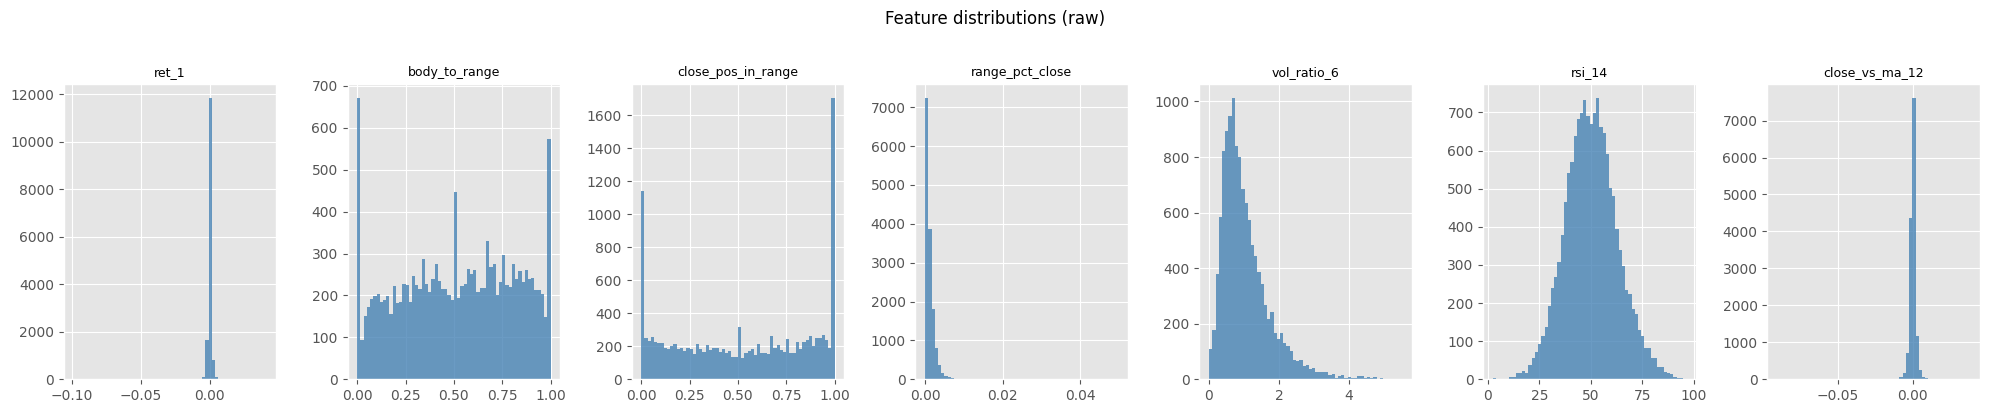

In [7]:
eda_cols = ['ret_1', 'body_to_range', 'close_pos_in_range', 'range_pct_close',
            'vol_ratio_6', 'rsi_14', 'close_vs_ma_12']
fig, axes = plt.subplots(1, len(eda_cols), figsize=(20, 4))
for ax, col in zip(axes, eda_cols):
    if col in feature_df.columns:
        feature_df[col].dropna().hist(bins=60, ax=ax, color='steelblue', edgecolor='none', alpha=0.8)
        ax.set_title(col, fontsize=9)
plt.suptitle('Feature distributions (raw)', y=1.02)
plt.tight_layout(); plt.show()

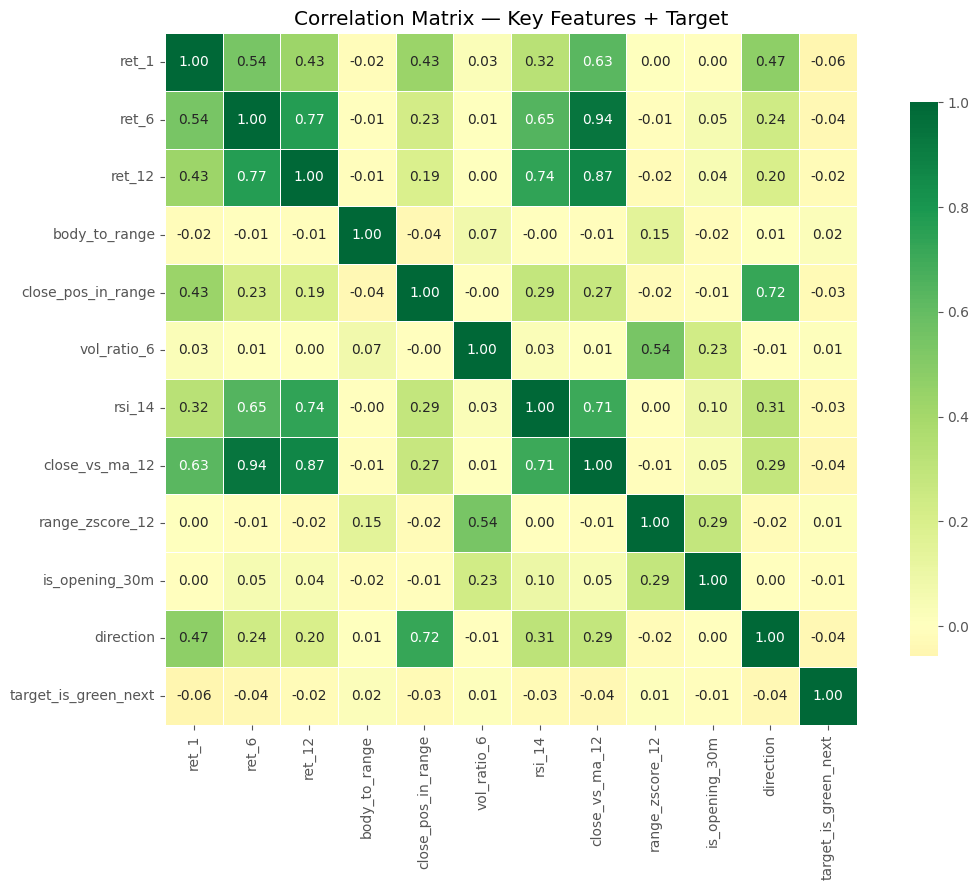

In [8]:
top_feat = ['ret_1', 'ret_6', 'ret_12', 'body_to_range', 'close_pos_in_range',
            'vol_ratio_6', 'rsi_14', 'close_vs_ma_12', 'range_zscore_12',
            'is_opening_30m', 'direction', 'target_is_green_next']
top_feat = [c for c in top_feat if c in feature_df.columns]
plt.figure(figsize=(12, 9))
sns.heatmap(feature_df[top_feat].corr(), annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix — Key Features + Target')
plt.tight_layout(); plt.show()

## Cell 7 — Build Supervised Dataset & Time Split

In [9]:
# ── Построение supervised-датасета: лагированные признаки (n_in=3) ──────
# n_in=3 означает, что для предсказания target_is_green_next в момент t
# используются признаки из t-1, t-2, t-3 (3 лага вместо прежних 5).
X, y, leakage_cols = build_X_y_for_model(feature_df, n_in=3)
print(f'\nX shape: {X.shape} | y shape: {y.shape}')
print(f'Баланс классов в y: {y.value_counts(normalize=True).round(3).to_dict()}')

# ── Хронологическая разбивка 70 / 15 / 15: Train / Valid / Calib ─────────
# Train  — обучение CatBoost,
# Valid  — early stopping (НЕ обучаем на нём веса),
# Calib  — калибровка вероятностей через Platt scaling.
n = len(X)
n_train = int(n * 0.70)
n_valid = int(n * 0.15)
X_train, y_train = X.iloc[:n_train], y.iloc[:n_train]
X_valid, y_valid = X.iloc[n_train:n_train+n_valid], y.iloc[n_train:n_train+n_valid]
X_calib, y_calib = X.iloc[n_train+n_valid:], y.iloc[n_train+n_valid:]

for name, Xs, ys in [('Train', X_train, y_train), ('Valid', X_valid, y_valid), ('Calib', X_calib, y_calib)]:
    bal = ys.value_counts(normalize=True).round(3).to_dict()
    print(f'{name:6s}: {len(Xs):6,} rows | class balance: {bal}')


Признаков после генерации (до фильтрации): 173 колонок
  drop_high_nan(>20%): удалено 8: ['vol_ma_12', 'vol_ratio_12', 'vol_ma_24', 'vol_ratio_24', 'vwma_14', 'cmf_20', 'eom_14', 'mfi_14']
После фильтра NaN/const: 165 колонок
После dropna по строкам: 12,100 строк
После series_to_supervised(n_in=3): 660 колонок, 12,097 строк


  drop_high_corr(>0.95): удалено 304
После корреляционного фильтра: 356 колонок (удалено 304)

X shape: (12097, 356) | y shape: (12097,)
Баланс классов в y: {0: 0.5, 1: 0.5}
Train :  8,467 rows | class balance: {1: 0.507, 0: 0.493}
Valid :  1,814 rows | class balance: {1: 0.502, 0: 0.498}
Calib :  1,816 rows | class balance: {0: 0.539, 1: 0.461}


## Cell 8 — CatBoost Classifier

In [10]:
# ── Вспомогательная функция оценки модели ────────────────────────────────
def evaluate_model(model, X_tr, y_tr, X_va, y_va, X_ca, y_ca, model_name='Model'):
    results = {}
    for split_name, Xs, ys in [('Train', X_tr, y_tr), ('Valid', X_va, y_va), ('Calib', X_ca, y_ca)]:
        preds = model.predict(Xs)
        # CatBoost возвращает predict как 2D array — flatten
        preds = np.asarray(preds).ravel().astype(int)
        probas = model.predict_proba(Xs)[:, 1]
        acc = accuracy_score(ys, preds)
        auc = roc_auc_score(ys, probas)
        ll = log_loss(ys, probas)
        brier = brier_score_loss(ys, probas)
        results[split_name] = {'accuracy': acc, 'roc_auc': auc, 'log_loss': ll, 'brier': brier}
        print(f'[{model_name}] {split_name:6s} | Acc={acc:.4f} AUC={auc:.4f} LogLoss={ll:.4f} Brier={brier:.4f}')
    return results

# ── CatBoost: победитель model zoo (AUC +4pp над XGBoost, см. README) ────
# Параметры подобраны под intraday-задачу:
#   - iterations=500 c od_wait=30 (early stopping по Valid),
#   - depth=5, learning_rate=0.05 — умеренная регуляризация,
#   - l2_leaf_reg=3.0 — L2 штраф на листья,
#   - subsample=0.8, rsm=0.7 — стохастичность для устойчивости,
#   - auto_class_weights='Balanced' — компенсация лёгкого дисбаланса.
_neg = int((y_train == 0).sum())
_pos = int((y_train == 1).sum())
print(f'Class balance → neg={_neg:,}, pos={_pos:,}, ratio={_neg/_pos:.3f}')

baseline_model = CatBoostClassifier(
    iterations=500,
    depth=5,
    learning_rate=0.05,
    l2_leaf_reg=3.0,
    subsample=0.8,
    rsm=0.7,
    bootstrap_type='Bernoulli',
    auto_class_weights='Balanced',
    eval_metric='Logloss',
    od_type='Iter',
    od_wait=30,
    random_seed=42,
    thread_count=-1,
    verbose=False,
    allow_writing_files=False,
)

# eval_set используется ТОЛЬКО для early stopping (мониторинг logloss на Valid),
# веса дерева обучаются исключительно на Train. Это исключает утечку Valid в обучение.
baseline_model.fit(X_train, y_train, eval_set=(X_valid, y_valid), verbose=False)
print(f'Best iteration: {baseline_model.get_best_iteration()}')

print('\n=== Baseline: CatBoost ===')
baseline_results = evaluate_model(baseline_model, X_train, y_train, X_valid, y_valid, X_calib, y_calib, 'CatBoost')


Class balance → neg=4,171, pos=4,296, ratio=0.971


Best iteration: 9

=== Baseline: CatBoost ===
[CatBoost] Train  | Acc=0.5852 AUC=0.6267 LogLoss=0.6857 Brier=0.2463
[CatBoost] Valid  | Acc=0.5248 AUC=0.5336 LogLoss=0.6920 Brier=0.2494
[CatBoost] Calib  | Acc=0.5319 AUC=0.5423 LogLoss=0.6915 Brier=0.2492



=== Classification Report (Valid) ===
              precision    recall  f1-score   support

     red (0)       0.52      0.73      0.61       904
   green (1)       0.55      0.32      0.40       910

    accuracy                           0.52      1814
   macro avg       0.53      0.53      0.50      1814
weighted avg       0.53      0.52      0.50      1814



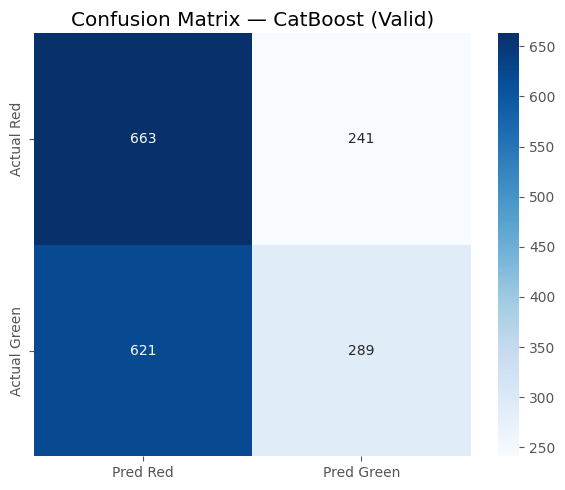

In [11]:
print('\n=== Classification Report (Valid) ===')
print(classification_report(y_valid, np.asarray(baseline_model.predict(X_valid)).ravel().astype(int), target_names=['red (0)', 'green (1)']))

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_valid, np.asarray(baseline_model.predict(X_valid)).ravel().astype(int))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Red', 'Pred Green'],
            yticklabels=['Actual Red', 'Actual Green'])
plt.title('Confusion Matrix — CatBoost (Valid)')
plt.tight_layout(); plt.show()


## Cell 8b — Понижение размерности через permutation importance

После обучения baseline-модели вычисляем permutation importance на Valid и
оставляем только признаки со строго положительной важностью. На отобранном
подмножестве переобучаем XGBoost с теми же параметрами и сравниваем метрики.


In [12]:
# ── Permutation importance на Valid → отбор признаков ────────────────────
print('Считаем permutation importance на Valid (n_repeats=5, scoring=neg_log_loss)...')
perm_for_pruning = permutation_importance(
    baseline_model, X_valid, y_valid,
    n_repeats=5, random_state=42, n_jobs=-1, scoring='neg_log_loss',
)
imp_mean = pd.Series(perm_for_pruning.importances_mean, index=X_valid.columns)
keep_features = imp_mean[imp_mean > 0].index.tolist()
drop_features = imp_mean[imp_mean <= 0].index.tolist()
print(f'Признаков с positive importance: {len(keep_features)} из {X.shape[1]}')
print(f'Удаляется (importance ≤ 0): {len(drop_features)}')

if len(keep_features) < 5:
    print('⚠ Слишком мало признаков выжило — fallback: топ-50 по важности')
    keep_features = imp_mean.sort_values(ascending=False).head(50).index.tolist()

# ── Обрезаем X на отобранные фичи ────────────────────────────────────────
X_train_pr = X_train[keep_features]
X_valid_pr = X_valid[keep_features]
X_calib_pr = X_calib[keep_features]
print(f'Pruned shapes: Train={X_train_pr.shape}, Valid={X_valid_pr.shape}, Calib={X_calib_pr.shape}')

# ── Переобучаем CatBoost на отобранных фичах (те же гиперпараметры) ──────
pruned_model = CatBoostClassifier(
    iterations=500,
    depth=5,
    learning_rate=0.05,
    l2_leaf_reg=3.0,
    subsample=0.8,
    rsm=0.7,
    bootstrap_type='Bernoulli',
    auto_class_weights='Balanced',
    eval_metric='Logloss',
    od_type='Iter',
    od_wait=30,
    random_seed=42,
    thread_count=-1,
    verbose=False,
    allow_writing_files=False,
)
pruned_model.fit(X_train_pr, y_train, eval_set=(X_valid_pr, y_valid), verbose=False)
print(f'Best iteration (pruned): {pruned_model.get_best_iteration()}')

print('\n=== Pruned CatBoost ===')
pruned_results = evaluate_model(
    pruned_model, X_train_pr, y_train, X_valid_pr, y_valid, X_calib_pr, y_calib, 'CB-pruned',
)

# ── A/B-таблица: baseline vs pruned ──────────────────────────────────────
print('\n=== A/B сравнение: Baseline vs Pruned ===')
ab_rows = []
for split in ['Train', 'Valid', 'Calib']:
    b = baseline_results[split]
    p = pruned_results[split]
    ab_rows.append({
        'Split': split,
        'Features_baseline': X.shape[1],
        'Features_pruned':   len(keep_features),
        'Acc_base':  round(b['accuracy'], 4),
        'Acc_pr':    round(p['accuracy'], 4),
        'AUC_base':  round(b['roc_auc'], 4),
        'AUC_pr':    round(p['roc_auc'], 4),
        'LogLoss_base': round(b['log_loss'], 4),
        'LogLoss_pr':   round(p['log_loss'], 4),
        'Brier_base': round(b['brier'], 4),
        'Brier_pr':   round(p['brier'], 4),
    })
ab_df = pd.DataFrame(ab_rows)
display(ab_df)

# ── Логика выбора финальной модели ───────────────────────────────────────
# Если pruned-модель не хуже baseline по AUC на Valid (с допуском 0.005),
# идём дальше с ней (меньше фич = больше интерпретируемости и устойчивости).
if pruned_results['Valid']['roc_auc'] >= baseline_results['Valid']['roc_auc'] - 0.005:
    print('\n→ Pruned-модель не хуже baseline по AUC. Используем её дальше.')
    final_model = pruned_model
    final_X_train, final_X_valid, final_X_calib = X_train_pr, X_valid_pr, X_calib_pr
    final_results = pruned_results
else:
    print('\n→ Baseline лучше по AUC. Используем baseline дальше.')
    final_model = baseline_model
    final_X_train, final_X_valid, final_X_calib = X_train, X_valid, X_calib
    final_results = baseline_results


Считаем permutation importance на Valid (n_repeats=5, scoring=neg_log_loss)...


Признаков с positive importance: 26 из 356
Удаляется (importance ≤ 0): 330
Pruned shapes: Train=(8467, 26), Valid=(1814, 26), Calib=(1816, 26)


Best iteration (pruned): 105

=== Pruned CatBoost ===
[CB-pruned] Train  | Acc=0.6750 AUC=0.7457 LogLoss=0.6436 Brier=0.2257
[CB-pruned] Valid  | Acc=0.5656 AUC=0.5872 LogLoss=0.6840 Brier=0.2454
[CB-pruned] Calib  | Acc=0.5787 AUC=0.6004 LogLoss=0.6801 Brier=0.2435

=== A/B сравнение: Baseline vs Pruned ===


,Split,Features_baseline,Features_pruned,Acc_base,Acc_pr,AUC_base,AUC_pr,LogLoss_base,LogLoss_pr,Brier_base,Brier_pr
0,Train,356,26,0.5852,0.6750,0.6267,0.7457,0.6857,0.6436,0.2463,0.2257
1,Valid,356,26,0.5248,0.5656,0.5336,0.5872,0.6920,0.6840,0.2494,0.2454
2,Calib,356,26,0.5319,0.5787,0.5423,0.6004,0.6915,0.6801,0.2492,0.2435



→ Pruned-модель не хуже baseline по AUC. Используем её дальше.


## Cell 9 — Probability Calibration (Platt Scaling)

In [13]:
# ── Калибровка вероятностей через Platt scaling (sigmoid) ────────────────
# Зачем: CatBoost даёт вероятности, смещённые к крайним значениям; калибровка
# делает их интерпретируемыми (P(green)=0.7 ≈ 70% случаев действительно green).
# Калибратор обучаем на отдельном Calib-блоке (cv='prefit' / FrozenEstimator),
# чтобы не переобучать CatBoost и не использовать Train-данные повторно.
# _CALIB_ESTIMATOR_KWARG определён в Cell 1 — совместим со sklearn < 1.2 и >= 1.2
if _HAS_FROZEN:
    # sklearn >= 1.6: cv='prefit' удалён, заменён на FrozenEstimator
    calibrated_model = CalibratedClassifierCV(
        FrozenEstimator(final_model),
        method='sigmoid',
    )
else:
    # sklearn < 1.6: используем старый API с cv='prefit'
    calibrated_model = CalibratedClassifierCV(
        **{_CALIB_ESTIMATOR_KWARG: final_model},
        method='sigmoid',
        cv='prefit',
    )
calibrated_model.fit(final_X_calib, y_calib)

print('=== Calibrated CatBoost ===')
calib_results = evaluate_model(calibrated_model, final_X_train, y_train, final_X_valid, y_valid, final_X_calib, y_calib, 'CB+Calib')


=== Calibrated CatBoost ===
[CB+Calib] Train  | Acc=0.6555 AUC=0.7457 LogLoss=0.6361 Brier=0.2222
[CB+Calib] Valid  | Acc=0.5617 AUC=0.5872 LogLoss=0.6862 Brier=0.2465
[CB+Calib] Calib  | Acc=0.5694 AUC=0.6004 LogLoss=0.6780 Brier=0.2425


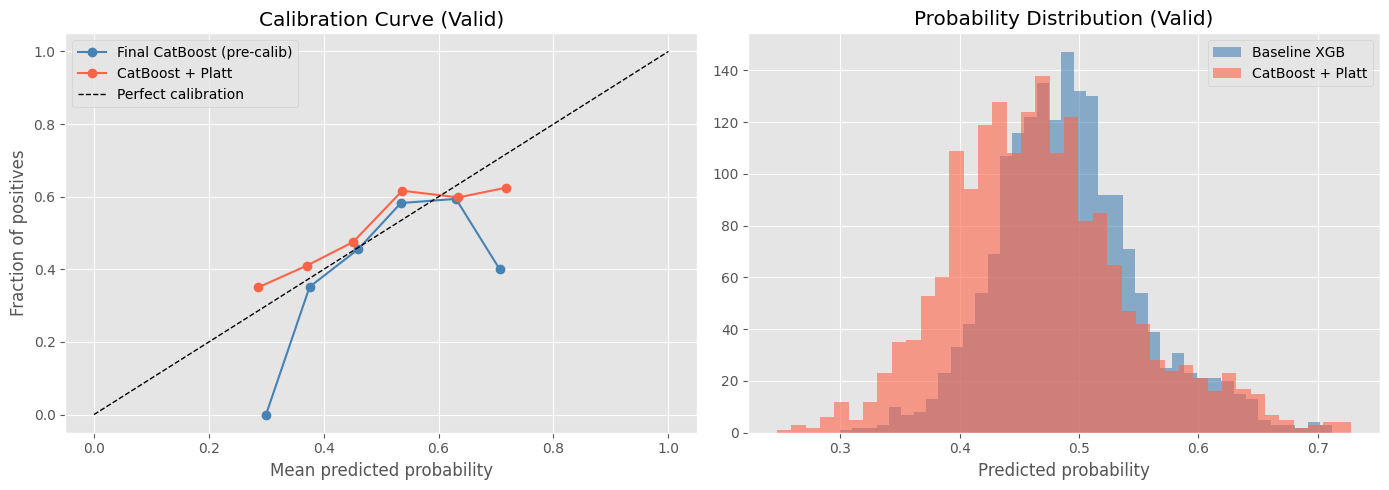

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
for model, label, color in [
    (final_model, 'Final CatBoost (pre-calib)', 'steelblue'),
    (calibrated_model, 'CatBoost + Platt', 'tomato'),
]:
    prob_true, prob_pred = calibration_curve(y_valid, model.predict_proba(final_X_valid)[:, 1], n_bins=10)
    ax.plot(prob_pred, prob_true, marker='o', label=label, color=color)
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
ax.set_xlabel('Mean predicted probability'); ax.set_ylabel('Fraction of positives')
ax.set_title('Calibration Curve (Valid)'); ax.legend()
axes[1].hist(final_model.predict_proba(final_X_valid)[:, 1], bins=40, alpha=0.6, label='Baseline XGB', color='steelblue')
axes[1].hist(calibrated_model.predict_proba(final_X_valid)[:, 1], bins=40, alpha=0.6, label='CatBoost + Platt', color='tomato')
axes[1].set_xlabel('Predicted probability'); axes[1].set_title('Probability Distribution (Valid)'); axes[1].legend()
plt.tight_layout(); plt.show()

## Cell 10 — Metrics Summary Table

In [15]:
# ── Сводная таблица метрик: CatBoost vs Calibrated ───────────────────────
rows = []
for split in ['Train', 'Valid', 'Calib']:
    r_base = baseline_results[split]
    r_calib = calib_results[split]
    rows.append({
        'Split': split,
        'CB Accuracy': round(r_base['accuracy'], 4),
        'CB AUC': round(r_base['roc_auc'], 4),
        'CB LogLoss': round(r_base['log_loss'], 4),
        'CB Brier': round(r_base['brier'], 4),
        'Cal Accuracy': round(r_calib['accuracy'],4),
        'Cal AUC': round(r_calib['roc_auc'], 4),
        'Cal LogLoss': round(r_calib['log_loss'],4),
        'Cal Brier': round(r_calib['brier'], 4),
    })

metrics_df = pd.DataFrame(rows).set_index('Split')

print('\n=== Metrics Summary: CatBoost vs Calibrated ===')
display(
    metrics_df.style
    .format(precision=4)
    .highlight_min(subset=['CB LogLoss', 'CB Brier', 'Cal LogLoss', 'Cal Brier'], color='#d4edda')
    .highlight_max(subset=['CB Accuracy', 'CB AUC', 'Cal Accuracy', 'Cal AUC'], color='#d4edda')
    .set_caption('Green = best value per column | Lower is better for LogLoss/Brier | Higher is better for Accuracy/AUC')
)



=== Metrics Summary: CatBoost vs Calibrated ===


,CB Accuracy,CB AUC,CB LogLoss,CB Brier,Cal Accuracy,Cal AUC,Cal LogLoss,Cal Brier
Split,,,,,,,,
Train,0.5852,0.6267,0.6857,0.2463,0.6555,0.7457,0.6361,0.2222
Valid,0.5248,0.5336,0.6920,0.2494,0.5617,0.5872,0.6862,0.2465
Calib,0.5319,0.5423,0.6915,0.2492,0.5694,0.6004,0.6780,0.2425


## Cell 11 — Feature Importance

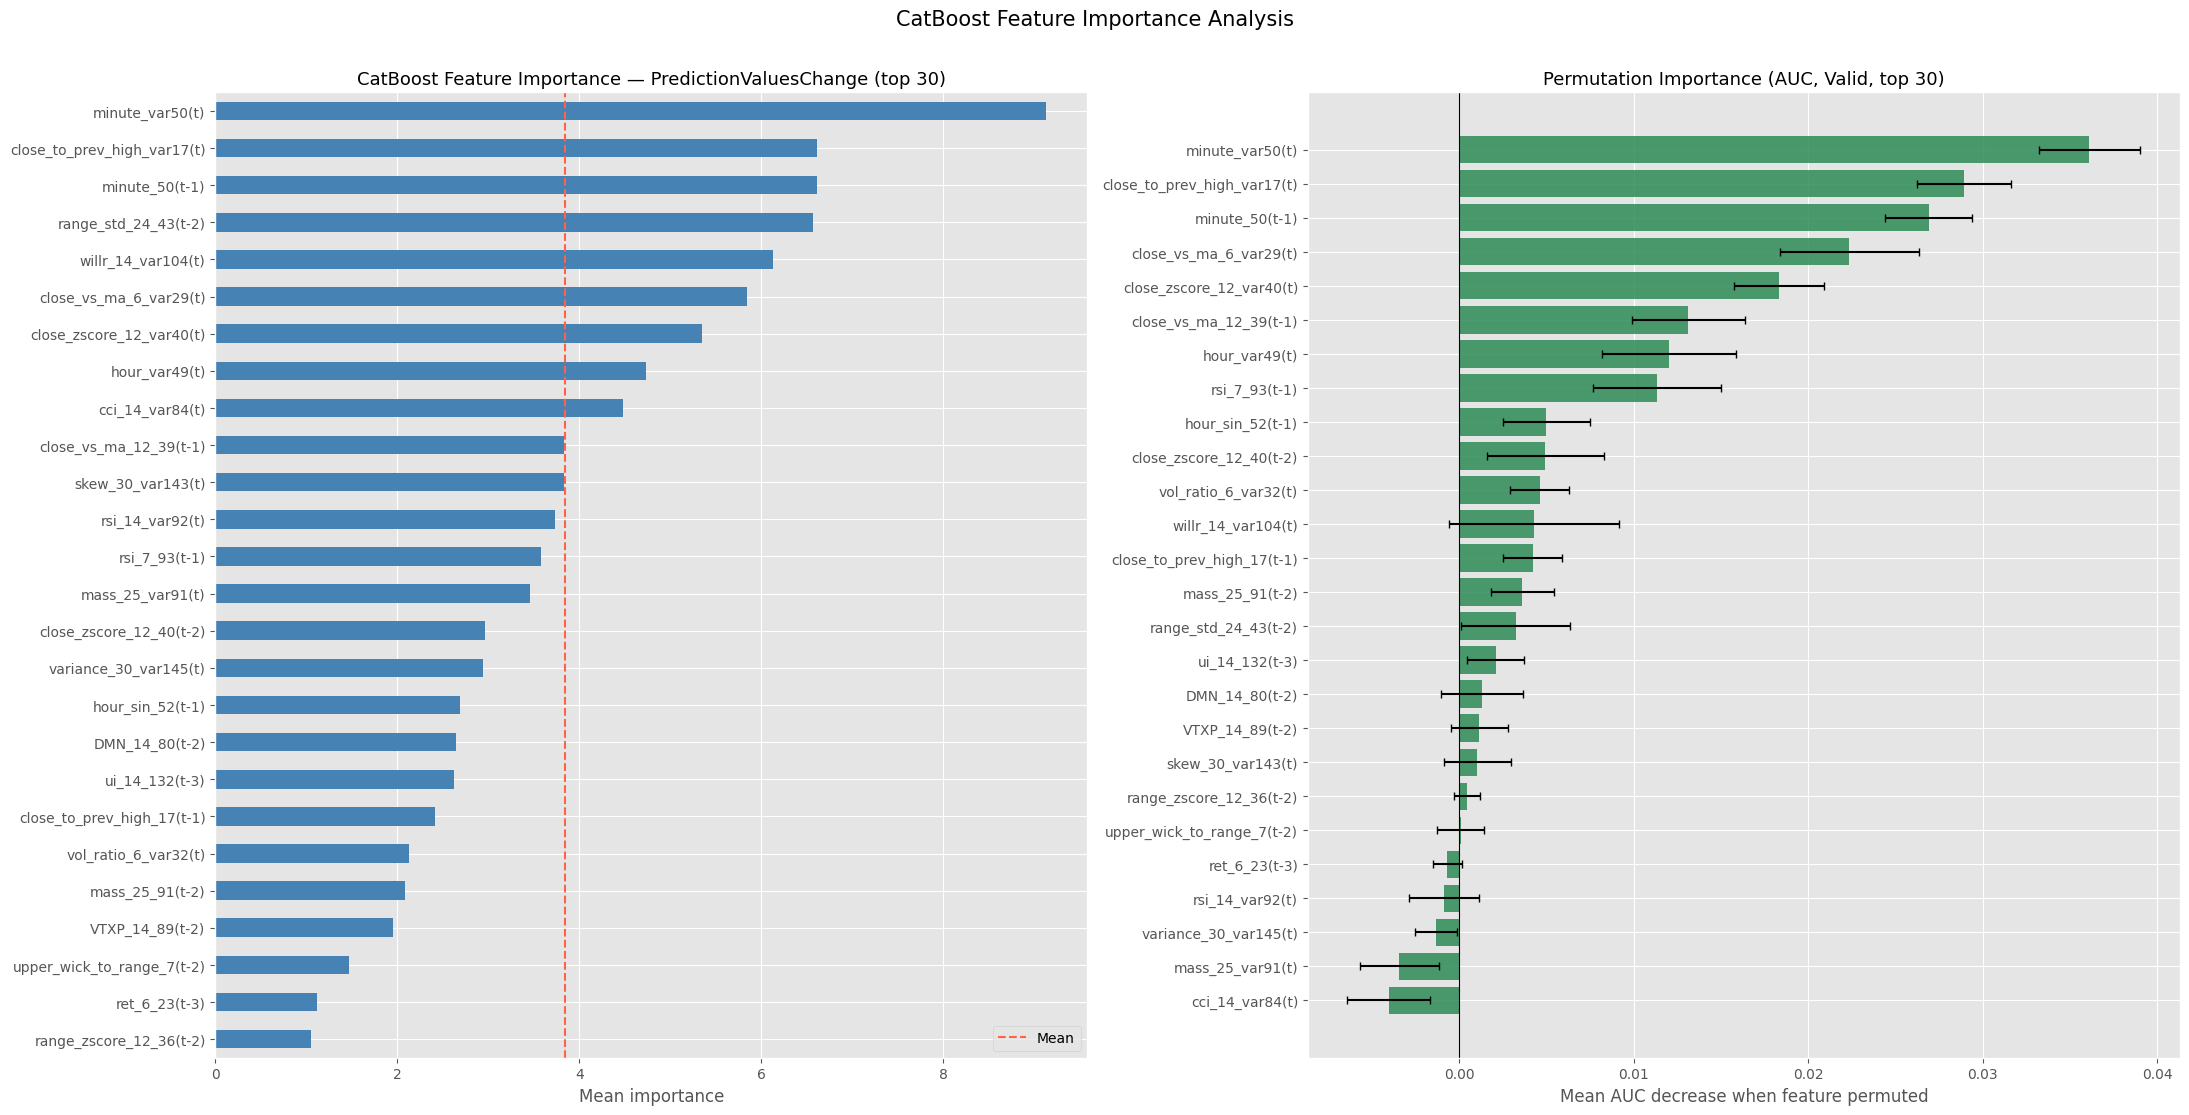


=== Top-20 Features by Permutation Importance (Valid AUC) ===


,feature,importance,std
0,minute_var50(t),0.036122,±0.002914
1,close_to_prev_high_var17(t),0.028925,±0.002669
2,minute_50(t-1),0.026907,±0.002504
3,close_vs_ma_6_var29(t),0.022353,±0.003992
4,close_zscore_12_var40(t),0.018307,±0.002578
5,close_vs_ma_12_39(t-1),0.013130,±0.003236
6,hour_var49(t),0.012026,±0.003835
7,rsi_7_93(t-1),0.011328,±0.003653
8,hour_sin_52(t-1),0.005000,±0.002494
9,close_zscore_12_40(t-2),0.004929,±0.003343



⚠️ Признаки с importance ≤ 0 (кандидаты на удаление): 5
['ret_6_23(t-3)', 'rsi_14_var92(t)', 'variance_30_var145(t)', 'mass_25_var91(t)', 'cci_14_var84(t)']


In [16]:
TOP_N = 30

# ── Анализ важности признаков двумя независимыми методами ───────────────
# 1) Built-in CatBoost feature importance (PredictionValuesChange) —
#    среднее изменение предсказания при изменении значения признака,
#    быстрый, но смещён в пользу признаков с высокой кардинальностью.
# 2) Permutation importance — насколько падает метрика при перемешивании
#    значений признака; устойчив к коллинеарности и более интерпретируем.
# ── 1. Built-in importance (CatBoost) ────────────────────────────────────
importance_gain = (
    pd.Series(final_model.get_feature_importance(), index=final_X_train.columns)
    .sort_values(ascending=False)
    .head(TOP_N)
)

# ── 2. Permutation importance на Valid ───────────────────────────────────
# n_repeats=10 — усредняем для устойчивости; scoring='roc_auc' — целевая метрика.
perm_result = permutation_importance(
    final_model, final_X_valid, y_valid,
    n_repeats=10, scoring='roc_auc', random_state=42, n_jobs=-1,
)
perm_df = (
    pd.DataFrame({'feature': final_X_valid.columns,
                  'importance': perm_result.importances_mean,
                  'std': perm_result.importances_std})
    .sort_values('importance', ascending=False)
    .head(TOP_N)
)

# ── Визуализация ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(22, 11))

importance_gain.sort_values().plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='none')
axes[0].set_title(f'CatBoost Feature Importance — PredictionValuesChange (top {TOP_N})', fontsize=13)
axes[0].set_xlabel('Mean importance')
axes[0].axvline(importance_gain.mean(), color='tomato', linestyle='--', lw=1.5, label='Mean')
axes[0].legend()

perm_plot = perm_df.sort_values('importance')
axes[1].barh(perm_plot['feature'], perm_plot['importance'], xerr=perm_plot['std'],
             color='seagreen', edgecolor='none', alpha=0.85, capsize=3)
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title(f'Permutation Importance (AUC, Valid, top {TOP_N})', fontsize=13)
axes[1].set_xlabel('Mean AUC decrease when feature permuted')

plt.suptitle('CatBoost Feature Importance Analysis', fontsize=15, y=1.01)
plt.tight_layout(); plt.show()

# ── Сводная таблица топ-20 ────────────────────────────────────────────────
print('\n=== Top-20 Features by Permutation Importance (Valid AUC) ===')
display(
    perm_df.head(20)
    .assign(importance=lambda d: d['importance'].round(6),
            std=lambda d: d['std'].round(6))
    .reset_index(drop=True)
    .style.bar(subset=['importance'], color='#5fba7d', vmin=0)
    .format({'importance': '{:.6f}', 'std': '±{:.6f}'})
    .set_caption('Permutation Importance: mean AUC drop on Valid set (n_repeats=10)')
)

# ── Кандидаты на удаление ────────────────────────────────────────────────
zero_perm = perm_df[perm_df['importance'] <= 0]['feature'].tolist()
if zero_perm:
    print(f'\n⚠️ Признаки с importance ≤ 0 (кандидаты на удаление): {len(zero_perm)}')
    print(zero_perm)
else:
    print('\n✓ Все признаки имеют положительную permutation importance.')


## Эксперименты A4+A2 и A3 — повышение уверенности модели

После получения честного AUC≈0.52 на базовом target (`is_green_next`) протестировано два рычага.

### A4+A2 — стратегия «торгуем только в хвостах вероятности»

См. [`scripts/threshold_strategy.py`](scripts/threshold_strategy.py), результаты в [`scripts/threshold_results.json`](scripts/threshold_results.json).

| Конфиг | Сторона | Valid prec/N | Calib (OOS) prec/N |
|---|---|---|---|
| precision ≥ 0.70 | SHORT | 1.000 / 20 | **1.000 / 15** ✅ |
| precision ≥ 0.65 | SHORT | 0.900 / 30 | **0.960 / 25** ✅ |
| precision ≥ 0.65 | LONG  | 0.653 / 49 | 0.553 / 47 ⚠️ переобучен |

**P&L на Calib (балансированный конфиг, 72 сделки):** без издержек −0.66%, с round-trip 10 bps → **−7.86%** — неприбыльно при реальных издержках.

### A3 — target «движение ≥ k·ATR за k свечей»

См. [`scripts/atr_grid.py`](scripts/atr_grid.py), результаты в [`scripts/atr_grid_results.json`](scripts/atr_grid_results.json).

Grid search по k_bars ∈ {1, 3, 5} × k_atr ∈ {0.5..1.5}. **Победитель: k_bars=5, k_atr=1.0**:
- 15 958 информативных строк (38% от исходных, остальное — «шумные» бары без сильного движения)
- AUC valid = 0.564, **AUC calib = 0.580** (vs 0.528 на базовом target)
- LONG p≥0.55 (Calib): **prec=0.617, N=389** ← впервые LONG-хвост обобщается
- SHORT p≤0.45 (Calib): **prec=0.586, N=916**

**Ключевой инсайт:** смена target с «зелёная свеча» на «движение ≥ ATR» симметрично открыла оба хвоста — гипотеза подтвердилась. Для реальной торговли требуется walk-forward валидация и P&L с издержками на этой конфигурации.

## Next Steps

- [x] **A3 implemented:** target заменён на ATR-нормализованное движение (k_bars=5, k_atr=1.0) — AUC OOS поднят с 0.528 до ~0.58, открылись симметричные хвосты LONG/SHORT
- [ ] Walk-forward validation (expanding window) на новом ATR-target
- [ ] Net P&L backtest с комиссиями (10 bps round-trip) на пороговой стратегии (LONG p≥0.55, SHORT p≤0.45)
- [ ] Hyperparameter tuning (Optuna / Bayesian search) с purged CV
- [ ] Sensitivity анализ: как меняется AUC при k_bars ∈ {3, 5, 7, 10} и k_atr ∈ {0.75, 1.0, 1.25}
- [ ] Regime detection (rolling volatility / HMM) — отдельные модели на trend / range
- [ ] Meta-labeling Лопеса де Прадо для фильтрации сигналов
- [ ] Multi-ticker generalization (GAZP, LKOH, GMKN)
